In [1]:
!nvidia-smi

Sun Apr 19 13:35:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F   # ReLU, dropout 등 함수형 API
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# This mounts your google drive storage to this code
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [3]:
# CUDA(GPU)가 사용 가능하면 GPU를 쓰고, 아니면 CPU 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# CIFAR-10 데이터셋을 저장할 구글 드라이브 경로
root = '/content/gdrive/My Drive/Test/'

# root = './'
# if not os.path.exists(root):
#     os.makedirs(root)

Using cuda device


In [4]:
# settings for data normalization
# CIFAR-10 의 채널별 평균과 표준편차 (공식적으로 알려진 값)
# 정규화를 하면 학습이 훨씬 빠르고 안정적으로 진행됨
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std  = (0.2470, 0.2435, 0.2616)

# 학습용 transform: 데이터 증강(Data Augmentation) 포함
#  - RandomCrop(32, padding=4): 이미지 주변에 4픽셀 패딩 후 32x32로 랜덤하게 잘라냄 → 위치 변화에 강건해짐
#  - RandomHorizontalFlip(): 50% 확률로 좌우 반전 → 데이터 양을 사실상 2배로 늘림
#  - ToTensor + Normalize: 텐서로 변환 후 정규화
train_trans = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

# 테스트용 transform: 데이터 증강 없이 정규화만 수행
# (테스트 시에는 원본 이미지로 평가해야 정확한 성능 측정 가능)
test_trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])


# CIFAR-10 학습 데이터셋 다운로드 및 로드
train_data = datasets.CIFAR10(
    root=root,
    train=True,
    download=True,
    transform=train_trans,
)

# CIFAR-10 테스트 데이터셋 다운로드 및 로드
test_data = datasets.CIFAR10(
    root=root,
    train=False,
    download=True,
    transform=test_trans,
)


# 배치 사이즈를 128로 설정 (CIFAR-10은 Fashion-MNIST 보다 이미지가 크므로 적절)
batch_size = 128
# num_workers: 데이터 로딩을 병렬 처리 → 학습 속도 향상
# pin_memory: GPU 로 텐서를 더 빠르게 전송하기 위한 옵션
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# CIFAR-10 의 10개 클래스 이름 (나중에 시각화할 때 사용)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"학습 데이터 개수: {len(train_data)}")
print(f"테스트 데이터 개수: {len(test_data)}")


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


학습 데이터 개수: 50000
테스트 데이터 개수: 10000


In [5]:
# # Linear Classification (참고용 - 단순 선형 분류기는 CIFAR-10에서 정확도 40%대로 매우 낮음)
# class LinearClassification(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.flatten = nn.Flatten()
#         self.linear = nn.Sequential(
#             nn.Linear(3*32*32, 10),   # CIFAR-10 은 3채널 32x32 컬러 이미지
#         )
#
#     def forward(self, x):
#         x = self.flatten(x)
#         logits = self.linear(x)
#         return logits
#
# model = LinearClassification().to(device)
# print(model)


In [6]:
# # Multi-layer Perceptron (참고용 - MLP도 CIFAR-10에서 50%대에 머무름)
# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.flatten = nn.Flatten()
#         self.linear_relu_stack = nn.Sequential(
#             nn.Linear(3*32*32, 512),
#             nn.ReLU(),
#             nn.Linear(512, 512),
#             nn.ReLU(),
#             nn.Linear(512, 10)
#         )
#
#     def forward(self, x):
#         x = self.flatten(x)
#         logits = self.linear_relu_stack(x)
#         return logits
#
# model = NeuralNetwork().to(device)
# print(model)


In [7]:
# define the CNN:
# VGG 스타일의 CNN — 3개의 Conv 블록 + 2개의 FC 층으로 구성
# 각 블록은 (Conv → BatchNorm → ReLU) × 2 + MaxPool 구조
#
# BatchNormalization: 각 층의 입력을 정규화 → 학습 안정성과 속도를 크게 향상시킴
# Dropout: 학습 시 일부 뉴런을 랜덤으로 끔 → 과적합 방지
#
# 이미지 크기 변화:
#   입력:   3 x 32 x 32
#   Block1 끝: 64 x 16 x 16   (MaxPool 2x2 적용)
#   Block2 끝: 128 x 8 x 8
#   Block3 끝: 256 x 4 x 4
#   Flatten → 4096 → 512 → 10

class MyConvNet(nn.Module):   # nn.Module should be inherited for the neural network configuration so that it can work with backpropagation APIs
    def __init__(self):    # define layers: three conv blocks and two linear (fully connected) layers
        super(MyConvNet, self).__init__()

        self.conv_layers = nn.Sequential(
            # ---------- Block 1: 3 → 64 channels ----------
            # kernel_size=3, padding=1 을 쓰면 공간 해상도가 그대로 유지됨 (32 → 32)
            nn.Conv2d(3,  64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),          # 배치 정규화로 학습 안정화
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32 → 16 (공간 크기 절반)

            # ---------- Block 2: 64 → 128 channels ----------
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16 → 8

            # ---------- Block 3: 128 → 256 channels ----------
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 8 → 4
        )

        # ---------- Fully Connected (완전연결) 층 ----------
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),              # 과적합 방지를 위해 50% 드롭아웃
            nn.Linear(256 * 4 * 4, 512),  # 4096 → 512
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)            # 512 → 10 (최종 클래스 개수)
        )

    # network connection: three conv blocks, each with two conv layers (+ BN + ReLU) and max-pooling, followed by two FC layers
    def forward(self, x):
        x = self.conv_layers(x)
        logits = self.fc_layers(x)
        return logits


# generate neural net model
# 모델 객체를 생성하고 GPU로 이동
model = MyConvNet().to(device)
print(model)

# 모델의 전체 학습 가능한 파라미터 개수 출력 (약 2~3백만 개 예상)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n학습 가능한 파라미터 개수: {num_params:,}")


MyConvNet(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d

In [8]:
# Optimizer 와 Loss function 정의
#
# Adam: SGD보다 수렴이 빠르고 하이퍼파라미터에 덜 민감 → 83% 목표 달성에 유리
# weight_decay: L2 정규화 효과로 과적합 방지 (가중치가 너무 커지지 않도록 패널티 부여)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

# CrossEntropyLoss: 분류 문제의 표준 손실함수 (softmax + negative log likelihood 를 합친 것)
criterion = nn.CrossEntropyLoss()

# Learning Rate Scheduler: 학습이 진행될수록 학습률을 코사인 곡선 모양으로 점점 감소시킴
# 초반에는 빠르게 학습하고 후반에는 세밀하게 조정 → 더 좋은 최종 정확도
num_epochs = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [9]:
# training and test

# 총 40 epoch 학습 (83% 달성을 위해 Fashion-MNIST 예제보다 더 많이 학습)
# data dimension: batch_size x Channels x Height x Width (NCHW)
#                 예) 128 x 3 x 32 x 32

best_acc = 0.0   # 지금까지 달성한 최고 정확도 기록용

for epoch in range(num_epochs):
    # ====== training phase ======
    model.train()   # 학습 모드 전환 (BatchNorm, Dropout 이 올바르게 동작하도록)
    current_loss = 0.0
    for batch_num, (x, target) in enumerate(train_loader):
        # 데이터와 타겟을 GPU로 이동
        x, target = x.to(device), target.to(device)

        # 순전파(forward) → 로짓 계산 → 손실 계산
        out = model(x)
        loss = criterion(out, target)

        # 역전파(backward) 및 가중치 업데이트
        optimizer.zero_grad()   # 이전 배치의 gradient 를 0으로 초기화
        loss.backward()         # 현재 배치에 대한 gradient 계산
        optimizer.step()        # 가중치 업데이트

        current_loss += loss.item()   # .item() 으로 스칼라 값만 추출 (메모리 누수 방지)

        # display the training loss in every 100 batches
        # 100 배치마다 학습 손실 출력 (학습이 제대로 진행되는지 모니터링)
        if (batch_num + 1) % 100 == 0 or (batch_num + 1) == len(train_loader):
            print('epoch: %d, batch_num: %d, current_loss: %.3f' % (epoch, batch_num + 1, current_loss / 100))
            current_loss = 0.0

    # 매 epoch 끝에서 learning rate 조정 (CosineAnnealing 스케줄에 따라)
    scheduler.step()

    # ====== test phase ======
    model.eval()   # 평가 모드 전환 (Dropout off, BatchNorm 은 이동평균 사용)
    with torch.no_grad():   # 기울기 계산을 하지 않음 → 메모리 절약 & 속도 향상
        total_samples = 0.0
        correct_samples = 0.0
        for (x, target) in test_loader:
            x, target = x.to(device), target.to(device)
            out = model(x)
            pred = torch.argmax(out, 1)                      # 가장 높은 확률을 가진 클래스 인덱스
            correct_samples += (pred == target).sum().item()  # 맞은 개수 누적
        acc = 100 * correct_samples / len(test_data)
        print('Epoch %d - Accuracy: %.3f%%  (LR=%.5f)' % (epoch, acc, scheduler.get_last_lr()[0]))

        # 최고 정확도 갱신 시 기록
        if acc > best_acc:
            best_acc = acc
            # 최고 성능 모델의 가중치를 메모리에 저장해두기
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

print('\n=== 학습 완료 ===')
print('최고 테스트 정확도: %.3f%%' % best_acc)

# 학습 종료 후, 저장해둔 최고 성능 가중치를 모델에 복원
model.load_state_dict(best_state)


epoch: 0, batch_num: 100, current_loss: 1.940
epoch: 0, batch_num: 200, current_loss: 1.611
epoch: 0, batch_num: 300, current_loss: 1.463
epoch: 0, batch_num: 391, current_loss: 1.225
Epoch 0 - Accuracy: 49.240%  (LR=0.00100)
epoch: 1, batch_num: 100, current_loss: 1.247
epoch: 1, batch_num: 200, current_loss: 1.182
epoch: 1, batch_num: 300, current_loss: 1.116
epoch: 1, batch_num: 391, current_loss: 0.982
Epoch 1 - Accuracy: 61.170%  (LR=0.00099)
epoch: 2, batch_num: 100, current_loss: 1.029
epoch: 2, batch_num: 200, current_loss: 0.987
epoch: 2, batch_num: 300, current_loss: 0.959
epoch: 2, batch_num: 391, current_loss: 0.842
Epoch 2 - Accuracy: 66.820%  (LR=0.00099)
epoch: 3, batch_num: 100, current_loss: 0.903
epoch: 3, batch_num: 200, current_loss: 0.867
epoch: 3, batch_num: 300, current_loss: 0.844
epoch: 3, batch_num: 391, current_loss: 0.757
Epoch 3 - Accuracy: 70.260%  (LR=0.00098)
epoch: 4, batch_num: 100, current_loss: 0.794
epoch: 4, batch_num: 200, current_loss: 0.786
epoc

<All keys matched successfully>

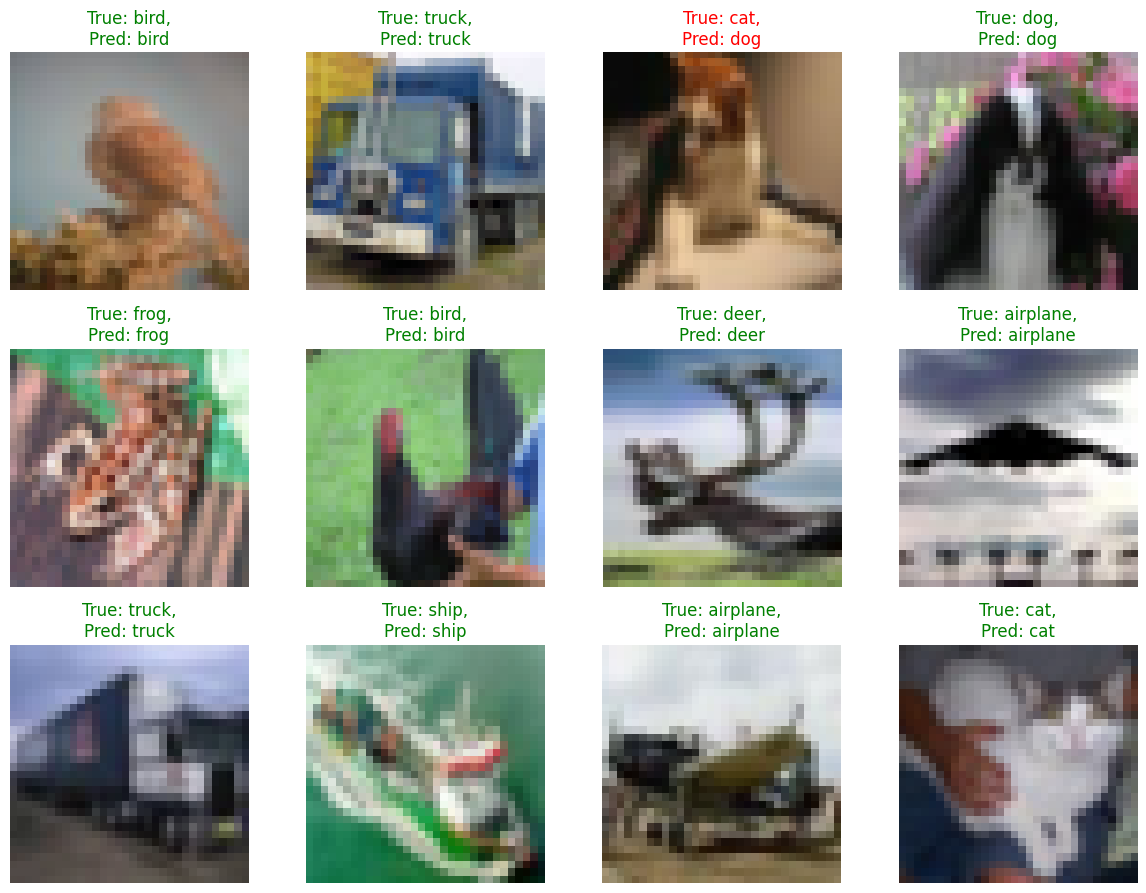

In [10]:
# Display Some test results
# 테스트 결과 시각화: 12개의 테스트 이미지를 랜덤으로 뽑아 예측 결과 확인
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 의 10개 클래스 이름
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

# take one batch of the data
# 테스트 로더에서 한 배치를 꺼냄
model.eval()   # 평가 모드
test_batch, test_labels = next(iter(test_loader))

# if cuda_available:
test_batch, test_labels = test_batch.to(device), test_labels.to(device)
with torch.no_grad():
    out = model(test_batch)             # put the test data to the trained network
    pred = torch.argmax(out, 1)         # prediction to the highest probability


# take 12 random sample index
sample_index = np.random.choice(batch_size, size=12, replace=False)
num_samples = sample_index.size

random_samples = test_batch[sample_index].cpu().numpy()

# 시각화를 위해 정규화를 역으로 풀어줌 (Normalize 는 이미지를 회색톤으로 만들어버리므로)
# 원래 이미지 = 정규화된 이미지 * std + mean
mean_np = np.array(cifar_mean).reshape(3, 1, 1)
std_np  = np.array(cifar_std).reshape(3, 1, 1)
random_samples = random_samples * std_np + mean_np        # denormalize
random_samples = np.clip(random_samples, 0, 1)            # 0~1 범위로 클리핑

plt.figure(figsize=(12, 12))

# display test samples
for k in range(num_samples):
    plt.subplot(4, 4, k + 1)
    # CIFAR-10 은 컬러 이미지이므로 (C,H,W) → (H,W,C) 로 축을 바꿔서 imshow
    img = np.transpose(random_samples[k], (1, 2, 0))
    plt.imshow(img)
    true_label = classes[test_labels[sample_index[k]].item()]
    pred_label = classes[pred[sample_index[k]].item()]
    # 정답/오답 색상 다르게 표시 (정답 초록, 오답 빨강)
    color = 'green' if true_label == pred_label else 'red'
    plt.title("True: " + true_label + ",\nPred: " + pred_label, color=color)
    plt.axis('off')


plt.tight_layout()
plt.show()

In [11]:
# save model
# 학습된 전체 모델 저장 (모델 구조 + 가중치)
torch.save(model, root + 'my_CIFAR10_CNN_model.pth')
print('모델이 저장되었습니다:', root + 'my_CIFAR10_CNN_model.pth')

# load model
# 저장된 모델을 로드하려면 아래 주석 해제
# model = torch.load(root + 'my_CIFAR10_CNN_model.pth')

모델이 저장되었습니다: /content/gdrive/My Drive/Test/my_CIFAR10_CNN_model.pth


In [12]:
# # save model weights
# # 가중치(state_dict)만 저장 — 용량이 더 작고 안정적인 방식 
# torch.save(model.state_dict(), root + 'cifar10_model_weights.pth')

# # load model weights
# # 가중치만 로드할 때는 먼저 같은 구조의 모델을 만든 뒤 state_dict 로 불러옴
# model = MyConvNet().to(device)
# model.load_state_dict(torch.load(root + 'cifar10_model_weights.pth'))
